In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns

import sys
sys.path.append('..')

This notebook is a guide for fetching data with the library of the project "". :)

Météo-France, CNRS, CNRM, Centre d’Etudes de la Neige \
Léo Catteau, Spring 2025

### Contents:
* [The Dataset ](#first-bullet)
* [Corruption process](#second-bullet)
* [Sample masking](#third-bullet)
* [Sequence masking](#fourth-bullet)
* [Window-horizon masking](#fifth-bullet)

There are up to now three types of training data, obtained through the data provider, with different masking procedures and different information available in the batches of dataloaders. 

### The Dataset <a class="anchor" id="first-bullet"></a>

In [2]:
from utils.functions import region_to_number

In [44]:
# dataset = xr.load_dataset('../../datasets/bdclim_safran_2022-2024.nc').transpose()
# dataset = xr.load_dataset('../../datasets/test_period_masked.nc').transpose()
dataset = xr.load_dataset('../../datasets/bdclim_SAFRAN_t_table_H_1950-2024_local.nc').transpose()
dataset = dataset.assign_coords(station_count=("num_poste", np.arange(len(dataset.num_poste))))
display(dataset)

<xarray.Dataset> Size: 12GB
Dimensions:              (time: 648673, num_poste: 2303)
Coordinates: (12/19)
  * time                 (time) datetime64[ns] 5MB 1950-01-01 ... 2024-01-01
  * num_poste            (num_poste) int64 18kB 1014002 1027003 ... 205026002
    Station_Name         (num_poste) <U30 276kB 'ARBENT' 'BALAN_AERO' ... 'FAHY'
    ZS                   (num_poste) int64 18kB 534 196 350 420 ... 485 411 596
    lat                  (num_poste) float64 18kB 46.28 45.83 ... 46.25 47.42
    lon                  (num_poste) float64 18kB 5.669 5.107 ... 6.128 6.941
    ...                   ...
    slope_30m            (num_poste) float32 9kB 2.644 0.928 ... 2.388 0.464
    slope_500m           (num_poste) float32 9kB 0.3522 0.6428 ... 0.4696 0.3549
    aspect_500m          (num_poste) float32 9kB 251.6 197.7 ... 11.98 205.6
    TPI_1000m            (num_poste) float32 9kB -30.38 -2.75 ... -12.25 11.62
    type_temps           (time) int64 5MB 8 8 8 8 8 8 8 8 8 ... 2 2 2 2 2 2 2 2
    station_count        (num_poste) int64 18kB 0 1 2 3 ... 2299 2300 2301 2302
Data variables:
    t                    (num_poste, time) float64 12GB nan nan nan ... 4.2 4.2

In [45]:
# dataset = xr.load_dataset('../../datasets/test_period.nc').transpose()
# dataset_masked = xr.load_dataset('../../datasets/test_period_masked.nc').transpose()
# # valid_stations = (dataset_masked['t'].count(dim='time') >= 5 * 365 * 24)
# # dataset = dataset.isel(num_poste=valid_stations)
# # dataset_masked = dataset_masked.isel(num_poste=valid_stations)
# display(dataset_masked)
# display(dataset)
# dataset.to_netcdf('../../datasets/test_period.nc')
# dataset_masked.to_netcdf('../../datasets/test_period_masked.nc')

In [46]:
# # # drop stations with less than 5 years data
# valid_stations = (dataset['t'].count(dim='time') >= 5 * 365 * 24)
# dataset = dataset.isel(num_poste=valid_stations)

In [47]:
# # dataset = dataset.where(dataset['t'].notnull().rolling({'time':24*365}).sum() >= 24*365, drop=True)
# dataset = dataset.sel({'num_poste':dataset['t'].notnull().sum(dim='time')>=24*365*5})
# dataset = dataset.assign_coords(station_count=("num_poste", np.arange(len(dataset.num_poste))))
# display(dataset)
# # dataset.to_netcdf('../../datasets/bdclim_safran_1950-2024_min3years.nc')

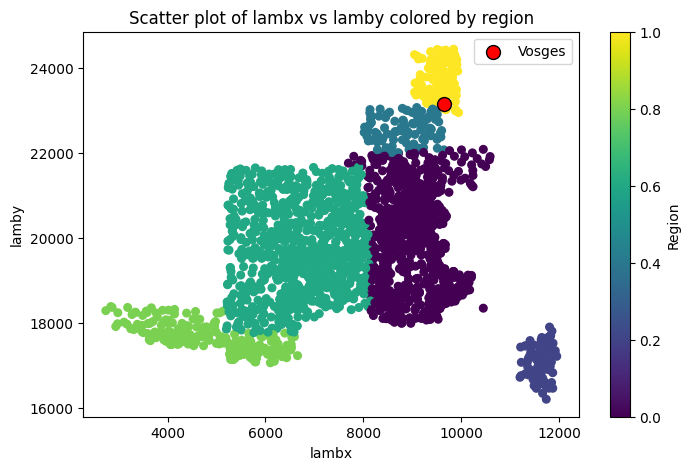

In [48]:
random_station = np.random.randint(0, len(dataset.num_poste))

predictors = dataset.reset_coords().drop_vars(['t','Station_Name','reseau_poste_actuel']).isel(time=0).to_dataframe().drop(columns='time')
predictors = predictors[['region', 'lambx', 'lamby']]

plt.figure(figsize=(8, 5))
plt.scatter(predictors['lambx'], predictors['lamby'], c=region_to_number(predictors['region']), cmap='viridis', s=30)
plt.scatter(predictors.iloc[random_station]['lambx'], predictors.iloc[random_station]['lamby'], label=predictors["region"].iloc[random_station], color='red', s=100, edgecolor='black')
plt.legend()
plt.title('Scatter plot of lambx vs lamby colored by region')
plt.xlabel('lambx')
plt.ylabel('lamby')
plt.colorbar(label='Region')
plt.show()

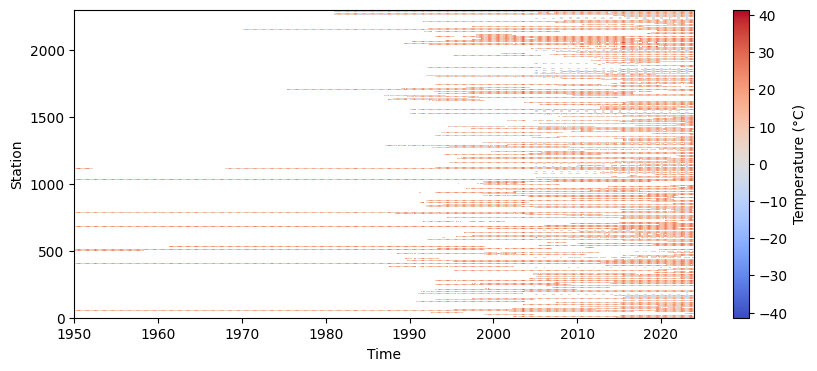

In [49]:
plt.figure(figsize=(10, 4))
# dataset['t'].plot(x='time', y='station_count', cbar_kwargs={'label': "Temperature (°C)"}, cmap='coolwarm')
coarse_dataset = dataset['t'].coarsen(time=24*7, boundary='trim').mean()
coarse_dataset.plot(x='time', y='station_count', cbar_kwargs={'label': "Temperature (°C)"}, cmap='coolwarm')
plt.xlabel("Time")
plt.ylabel("Station")
plt.show()

Text(0.5, 1.0, 'station 1668')

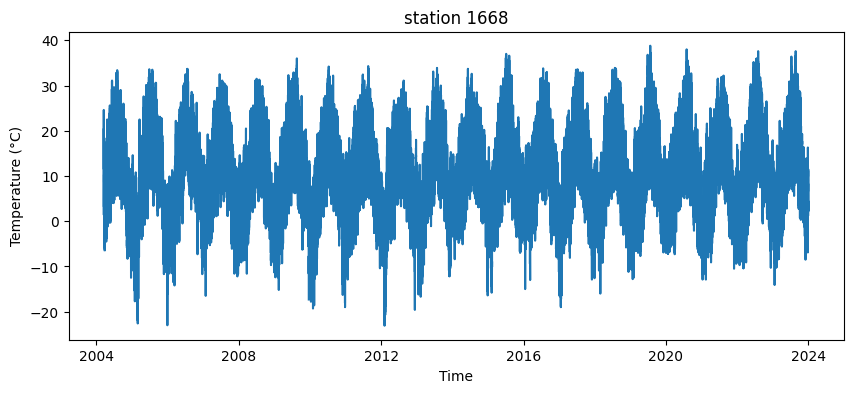

In [50]:
plt.figure(figsize=(10, 4))
dataset['t'].sel(num_poste=random_station, method='nearest').plot(x='time')
plt.xlabel("Time")
plt.ylabel("Temperature (°C)")
plt.title("station " + str(random_station))

### Corruption process <a class="anchor" id="second-bullet"></a>

In [51]:
from scipy.stats import gaussian_kde

/home/catteaul/meteo-impute/.venv2/lib/python3.12/site-packages/xarray/core/duck_array_ops.py:237: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)


[nan nan nan ... nan nan nan]


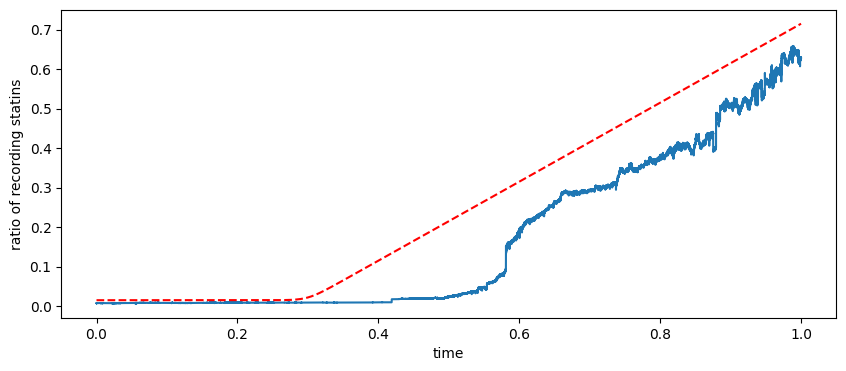

In [52]:
plt.figure(figsize=(10,4))
data_ratio = np.array((dataset['t'].notnull().sum(dim='num_poste').rolling(time=30, center=True).mean()/len(dataset.num_poste)).values)
print(data_ratio)
plt.plot(np.linspace(0,1,len(data_ratio)),data_ratio)
# fit = np.polyfit(data_ratio.time.values, data_ratio.values, 1)
# plt.plot(data_ratio.time, fit[0]*data_ratio.time + fit[1], color='red', linestyle='--', label='linear fit')
a = .8
b = 100
c = 0.015
plt.plot(np.linspace(0,1,len(data_ratio)), c+(1/b)*np.log(1+np.exp(50+b*(np.linspace(0,1,len(data_ratio))-a))), linestyle="--", color="red")
plt.xlabel('time')
plt.ylabel('ratio of recording statins')
plt.show()

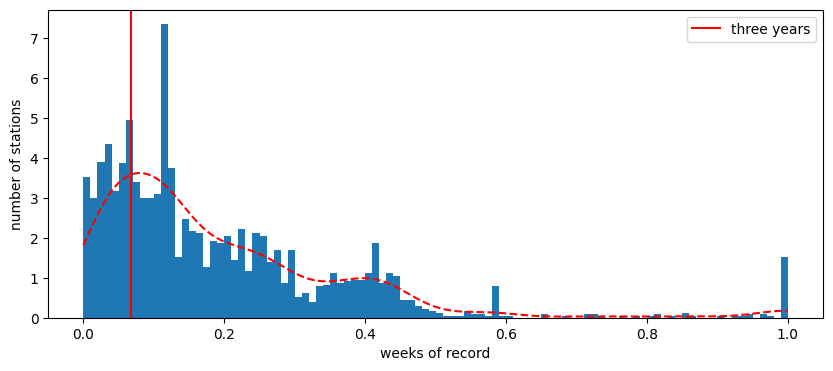

In [53]:
data = (coarse_dataset.notnull().sum(dim='time')/len(coarse_dataset.time)).values.flatten()
kde = gaussian_kde(data)
x = np.linspace(min(data), max(data), 500)

plt.figure(figsize=(10,4))
plt.hist(data, bins=100, density=True)
plt.axvline(365*5/7/len(coarse_dataset.time), label='three years', linestyle='-', color='red')
plt.plot(x, kde(x), color='red', linestyle='--')
plt.legend()
plt.xlabel('weeks of record')
plt.ylabel('number of stations')
plt.show()

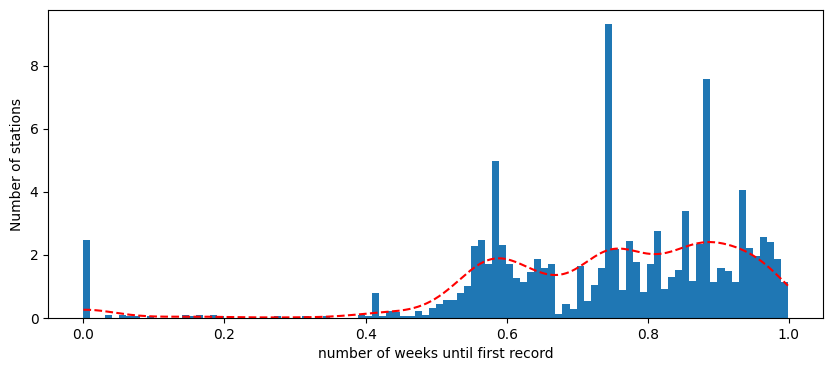

In [54]:
data = (coarse_dataset.isnull().argmin(dim='time')/len(coarse_dataset.time)).values.flatten()
kde_start = gaussian_kde(data)
x = np.linspace(min(data), max(data), 500)

plt.figure(figsize=(10,4))
plt.hist(data, bins=100, density=True)
plt.plot(x, kde_start(x), color='red', linestyle='--')
plt.xlabel('number of weeks until first record')
plt.ylabel('Number of stations')
plt.show()

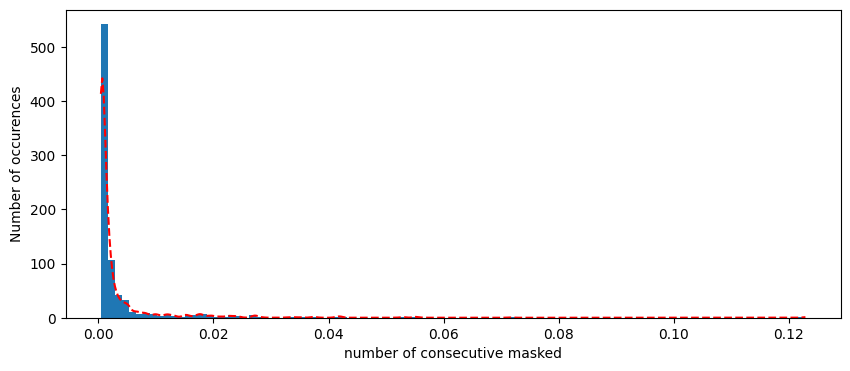

In [55]:
first_valid = (~coarse_dataset.isnull().data).argmax(axis=0)
for i, idx in enumerate(first_valid):
    coarse_dataset.isnull().data[:idx, i] = False

def get_nan_lengths(bool_array):
    isnan = bool_array
    diffs = np.diff(np.concatenate(([0], isnan.view(np.int8), [0])))
    run_starts = np.where(diffs==1)[0]
    run_ends = np.where(diffs==-1)[0]
    return run_ends - run_starts

all_run_lengths = []
for i in range(coarse_dataset.isnull().data.shape[1]):
    lengths = get_nan_lengths(coarse_dataset.isnull().data[:,i])
    all_run_lengths.extend(lengths)

data = np.array(all_run_lengths)/len(coarse_dataset.num_poste)
kde_length = gaussian_kde(data)
x = np.linspace(min(data), max(data), 500)

plt.figure(figsize=(10,4))
plt.hist(data, bins=100, density=True)
plt.plot(x, kde_length(x), color='red', linestyle='--')
# plt.yscale('log')
plt.xlabel('number of consecutive masked')
plt.ylabel('Number of occurences')
plt.show()

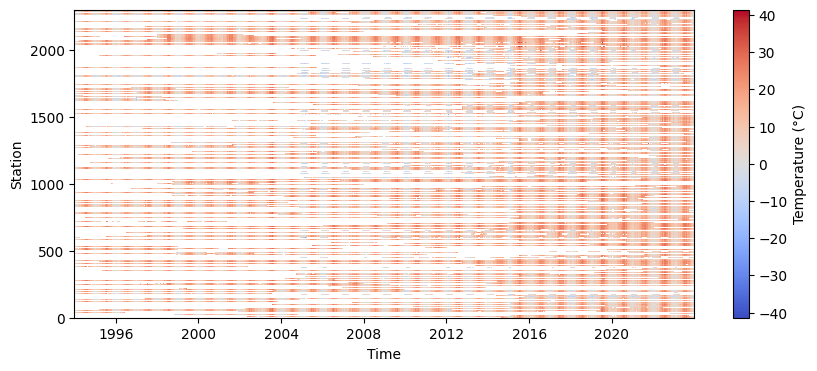

In [56]:
training_dataset = dataset.sel(time = slice('1994','2024'))
training_dataset = training_dataset.assign_coords(station_count=("num_poste", np.arange(len(training_dataset.num_poste))))
plt.figure(figsize=(10, 4))
coarse_dataset = training_dataset['t'].coarsen(time=24*7, boundary='trim').mean()
coarse_dataset.plot(x='time', y='station_count', cbar_kwargs={'label': "Temperature (°C)"}, cmap='coolwarm')
plt.xlabel("Time")
plt.ylabel("Station")
plt.show()

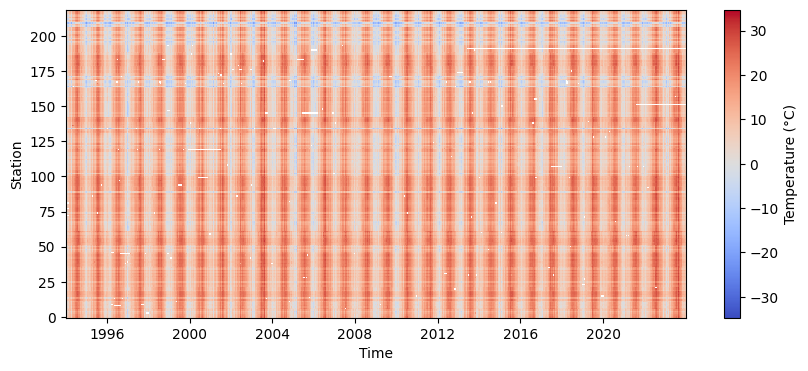

In [57]:
training_dataset = dataset.sel(time = slice('1994','2024'))
training_dataset = training_dataset.sel({'num_poste':dataset['t'].notnull().sum(dim='time')>=24*365*30})
training_dataset = training_dataset.assign_coords(station_count=("num_poste", np.arange(len(training_dataset.num_poste))))
plt.figure(figsize=(10, 4))
coarse_dataset = training_dataset['t'].coarsen(time=24*7, boundary='trim').mean()
coarse_dataset.plot(x='time', y='station_count', cbar_kwargs={'label': "Temperature (°C)"}, cmap='coolwarm')
plt.xlabel("Time")
plt.ylabel("Station")
plt.show()

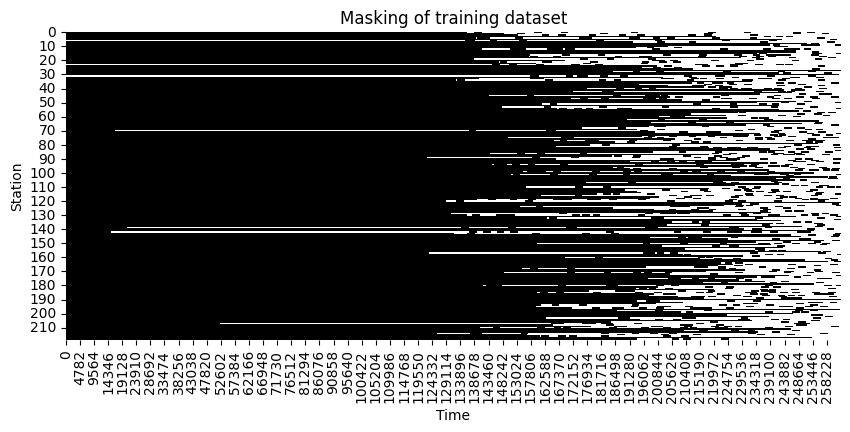

In [58]:
# Provided functions
def masking_proba(time): # time should be normalized between 0 and 1
    return .0015 + (1/100) * np.log(1 + np.exp(50 + 100*(time) - .8))

# Sample mask start times for each station
mask_starts = kde_start.resample(size=len(training_dataset.num_poste)).squeeze()

# Initialize mask (True = keep, False = masked)
mask = np.ones_like(training_dataset['t'].data, dtype=bool)

# Normalize time index between 0 and 1
num_time_steps = training_dataset.time.size
time_normalized = np.linspace(0, 1, num_time_steps)

for i in range(len(training_dataset.num_poste)):
    start_idx = int(mask_starts[i] * num_time_steps)
    if start_idx<num_time_steps*0.05:
        start_idx=0
    mask[i,:start_idx] = False

# # Trop long
# for i in range(len(training_dataset.num_poste)):
#     start_idx = int(mask_starts[i] * num_time_steps)
#     t = start_idx
#     while t < num_time_steps:
#         # Check if a mask should be applied at this time step
#         if np.random.rand() < masking_proba(time_normalized[t]):
#             # Sample mask length
#             L = int(np.clip(kde_length.resample(1)[0], 1, num_time_steps - t))
#             mask[i, t:t+L] = False
#             t += L # Skip over the masked interval
#         else:
#             t += 1 # Move to next time step

## moins long (idéalement suppose un processus de masking\apparition uniforme)
mask_length = 0.01 * num_time_steps
mask_proba = 0.2
eval_mask = np.array(np.random.rand(num_time_steps, len(training_dataset.num_poste)) > mask_proba/mask_length, dtype=bool)
masked_indices =  np.where(~eval_mask)
for i,j in zip(masked_indices[0], masked_indices[1]):
    start = max(0, i - int(0.5 * mask_length))
    end = min(num_time_steps, i + int(0.5 * mask_length))
    if i>int(num_time_steps*(1/2)):
        eval_mask[start:end, j] = False

eval_mask = eval_mask.T
mask[~eval_mask] = False

# Plot the mask
plt.figure(figsize=(10, 4))
sns.heatmap(mask, cmap='gray', cbar=False)
plt.xlabel("Time")
plt.ylabel("Station")
plt.title("Masking of training dataset")
plt.show()

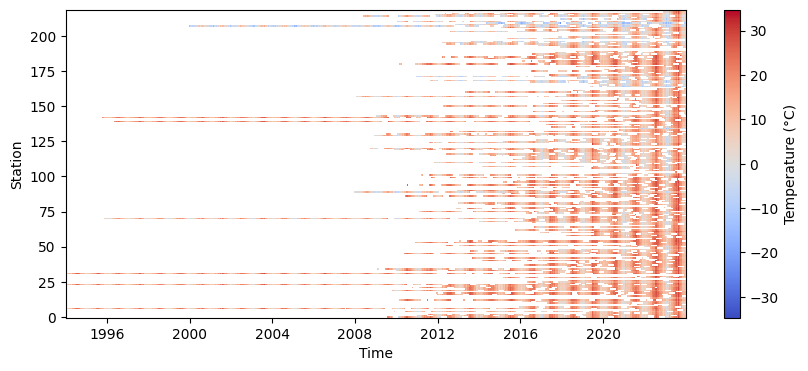

In [59]:
corrupted_training_dataset = training_dataset.copy()
corrupted_training_dataset['t'].values[~mask] = np.nan

# fig, ax = plt.subplots(2, 1, figsize=(10, 6))
# sns.heatmap(training_dataset['t'].values.T, xticklabels=False, yticklabels=False, cmap="coolwarm", ax=ax[0])
# ax[0].set_title("Original data")
# ax[0].set_xlabel("Time")
# ax[0].set_ylabel("Station")
# sns.heatmap(corrupted_training_dataset['t'].values.T, xticklabels=False, yticklabels=False, cmap="coolwarm", ax=ax[1])
# ax[1].set_title("Corrupted data")
# ax[1].set_xlabel("Time")
# ax[1].set_ylabel("Station")
# plt.show()

plt.figure(figsize=(10, 4))
coarse_dataset = corrupted_training_dataset['t'].coarsen(time=24*7, boundary='trim').mean()
coarse_dataset.plot(x='time', y='station_count', cbar_kwargs={'label': "Temperature (°C)"}, cmap='coolwarm')
plt.xlabel("Time")
plt.ylabel("Station")
plt.show()

<xarray.Dataset> Size: 379MB
Dimensions:              (time: 262969, num_poste: 178)
Coordinates: (12/19)
  * time                 (time) datetime64[ns] 2MB 1994-01-01 ... 2024-01-01
  * num_poste            (num_poste) int64 1kB 1089001 3059001 ... 205026002
    Station_Name         (num_poste) <U30 21kB 'AMBERIEU' ... 'FAHY'
    ZS                   (num_poste) int64 1kB 250 286 249 650 ... 1017 485 596
    lat                  (num_poste) float64 1kB 45.98 46.28 ... 47.0 47.42
    lon                  (num_poste) float64 1kB 5.329 3.226 ... 6.953 6.941
    ...                   ...
    slope_30m            (num_poste) float32 712B 0.7337 1.64 ... 6.866 0.464
    slope_500m           (num_poste) float32 712B 0.68 0.829 ... 4.772 0.3549
    aspect_500m          (num_poste) float32 712B 202.9 130.9 ... 163.3 205.6
    TPI_1000m            (num_poste) float32 712B 2.125 -0.25 ... -44.38 11.62
    type_temps           (time) int64 2MB 2 2 2 2 2 2 2 2 2 ... 2 2 2 2 2 2 2 2
    station_count        (num_poste) int64 1kB 0 1 2 3 4 ... 213 214 215 216 218
Data variables:
    t                    (num_poste, time) float64 374MB nan nan nan ... 4.2 4.2

<xarray.Dataset> Size: 379MB
Dimensions:              (time: 262969, num_poste: 178)
Coordinates: (12/19)
  * time                 (time) datetime64[ns] 2MB 1994-01-01 ... 2024-01-01
  * num_poste            (num_poste) int64 1kB 1089001 3059001 ... 205026002
    Station_Name         (num_poste) <U30 21kB 'AMBERIEU' ... 'FAHY'
    ZS                   (num_poste) int64 1kB 250 286 249 650 ... 1017 485 596
    lat                  (num_poste) float64 1kB 45.98 46.28 ... 47.0 47.42
    lon                  (num_poste) float64 1kB 5.329 3.226 ... 6.953 6.941
    ...                   ...
    slope_30m            (num_poste) float32 712B 0.7337 1.64 ... 6.866 0.464
    slope_500m           (num_poste) float32 712B 0.68 0.829 ... 4.772 0.3549
    aspect_500m          (num_poste) float32 712B 202.9 130.9 ... 163.3 205.6
    TPI_1000m            (num_poste) float32 712B 2.125 -0.25 ... -44.38 11.62
    type_temps           (time) int64 2MB 2 2 2 2 2 2 2 2 2 ... 2 2 2 2 2 2 2 2
    station_count        (num_poste) int64 1kB 0 1 2 3 4 ... 213 214 215 216 218
Data variables:
    t                    (num_poste, time) float64 374MB nan nan nan ... 4.2 4.2

<xarray.Dataset> Size: 152MB
Dimensions:              (time: 105193, num_poste: 178)
Coordinates: (12/19)
  * time                 (time) datetime64[ns] 842kB 2012-01-01 ... 2024-01-01
  * num_poste            (num_poste) int64 1kB 1089001 3059001 ... 205026002
    Station_Name         (num_poste) <U30 21kB 'AMBERIEU' ... 'FAHY'
    ZS                   (num_poste) int64 1kB 250 286 249 650 ... 1017 485 596
    lat                  (num_poste) float64 1kB 45.98 46.28 ... 47.0 47.42
    lon                  (num_poste) float64 1kB 5.329 3.226 ... 6.953 6.941
    ...                   ...
    slope_30m            (num_poste) float32 712B 0.7337 1.64 ... 6.866 0.464
    slope_500m           (num_poste) float32 712B 0.68 0.829 ... 4.772 0.3549
    aspect_500m          (num_poste) float32 712B 202.9 130.9 ... 163.3 205.6
    TPI_1000m            (num_poste) float32 712B 2.125 -0.25 ... -44.38 11.62
    type_temps           (time) int64 842kB 2 2 2 2 2 2 2 2 ... 2 2 2 2 2 2 2 2
    station_count        (num_poste) int64 1kB 0 1 2 3 4 ... 213 214 215 216 218
Data variables:
    t                    (num_poste, time) float64 150MB 6.9 7.1 7.2 ... 4.2 4.2

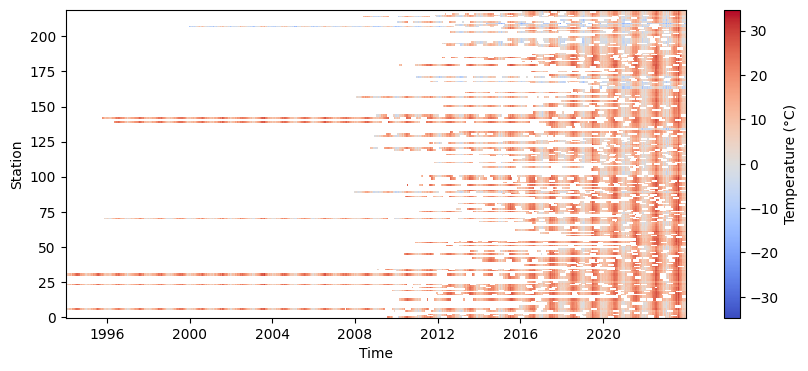

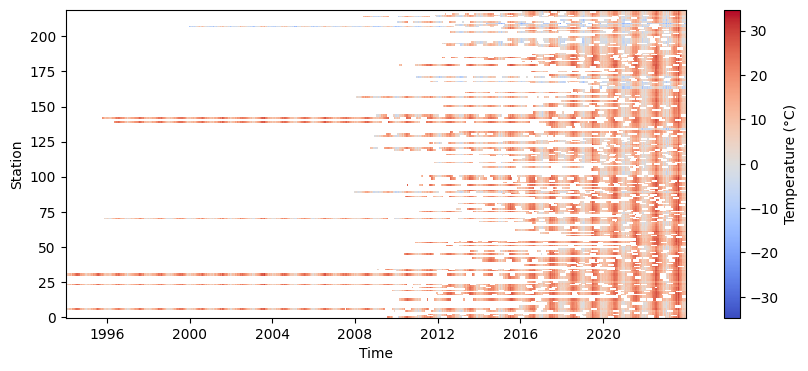

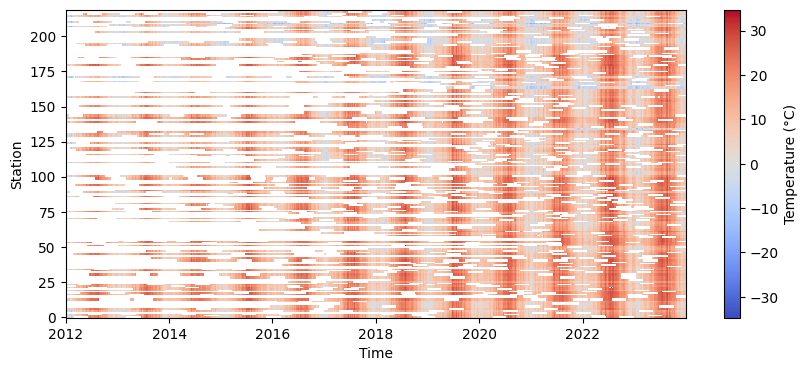

In [61]:
valid_stations = (corrupted_training_dataset['t'].count(dim='time') >= 2 * 365 * 24)
test_period = training_dataset.isel(num_poste=valid_stations)
test_period_masked = corrupted_training_dataset.isel(num_poste=valid_stations)
train_test_period_masked = test_period_masked.sel(time = slice('2012','2024'))
display(test_period)
display(test_period_masked)
display(train_test_period_masked)

plt.figure(figsize=(10, 4))
coarse_dataset = test_period['t'].coarsen(time=24*7, boundary='trim').mean()
coarse_dataset.plot(x='time', y='station_count', cbar_kwargs={'label': "Temperature (°C)"}, cmap='coolwarm')
plt.xlabel("Time")
plt.ylabel("Station")
plt.show()

plt.figure(figsize=(10, 4))
coarse_dataset = test_period_masked['t'].coarsen(time=24*7, boundary='trim').mean()
coarse_dataset.plot(x='time', y='station_count', cbar_kwargs={'label': "Temperature (°C)"}, cmap='coolwarm')
plt.xlabel("Time")
plt.ylabel("Station")
plt.show()

plt.figure(figsize=(10, 4))
coarse_dataset = train_test_period_masked['t'].coarsen(time=24*7, boundary='trim').mean()
coarse_dataset.plot(x='time', y='station_count', cbar_kwargs={'label': "Temperature (°C)"}, cmap='coolwarm')
plt.xlabel("Time")
plt.ylabel("Station")
plt.show()


test_period.to_netcdf('../../datasets/test_period.nc')
test_period_masked.to_netcdf('../../datasets/test_period_masked.nc')
train_test_period_masked.to_netcdf('../../datasets/train_test_period_masked.nc')

### Sample masking <a class="anchor" id="third-bullet"></a>

In [2]:
from data_provider.data_provider import DataProvider
from types import SimpleNamespace

/Users/leocatteau/opt/anaconda3/lib/python3.9/site-packages/dask/dataframe/_pyarrow_compat.py:17: FutureWarning: Minimal version of pyarrow will soon be increased to 14.0.1. You are using 11.0.0. Please consider upgrading.
  warnings.warn(
/Users/leocatteau/opt/anaconda3/lib/python3.9/site-packages/umap/plot.py:203: NumbaDeprecationWarning: The keyword argument 'nopython=False' was supplied. From Numba 0.59.0 the default is being changed to True and use of 'nopython=False' will raise a warning as the argument will have no effect. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit(nopython=False)


In [3]:
args = SimpleNamespace()
args.data = 'bdclim_clean'
args.dataset = 'SampleMaskDataset'
args.root_path = '../../datasets/'
args.data_path = 'bdclim_safran_2022-2024.nc'
args.has_predictors = False
args.scaler = None
args.batch_size = 1
args.mask_proba = 0.0

data_provider = DataProvider(args)

total stations:  2303  remaining stations:  443  removing every station with NaN values.
exogenous variables shape:  (17521, 443)
exogenous variables:  [[2 2 2 ... 2 2 2]
 [2 2 2 ... 2 2 2]
 [2 2 2 ... 2 2 2]
 ...
 [2 2 2 ... 2 2 2]
 [2 2 2 ... 2 2 2]
 [2 2 2 ... 2 2 2]]
predictors shape:  (443, 10)
predictors:  Index(['ZS', 'lambx', 'lamby', 'TCD_500m', 'TPI_30m', 'aspect_30m',
       'slope_30m', 'slope_500m', 'aspect_500m', 'TPI_1000m'],
      dtype='object')
mask shape:  (17521, 443)
mask:  [[1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 ...
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]]
device:  cpu


Mask shape: torch.Size([8761, 1562])


<Axes: ylabel='Count'>

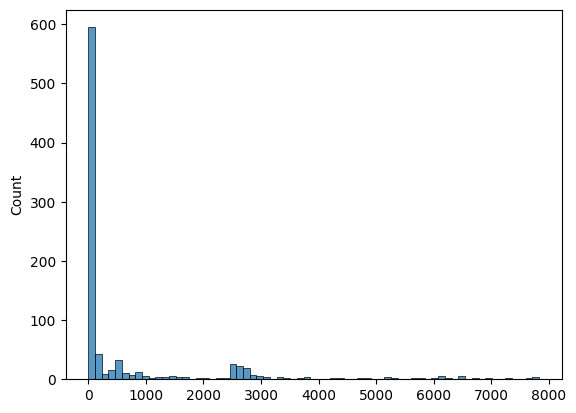

In [4]:
mask = ~data_provider.dataset.mask
print("Mask shape:", mask.shape)

# sns.heatmap(mask.T, cmap='viridis', cbar_kws={'label': 'Missing Data Mask'})

mask_lengths = []
for i in range(mask.shape[1]):
    mask_lengths.append(mask[:, i].sum().item())
# drop zeros from mask lengths
mask_lengths = [length for length in mask_lengths if length > 0]

sns.histplot(mask_lengths)

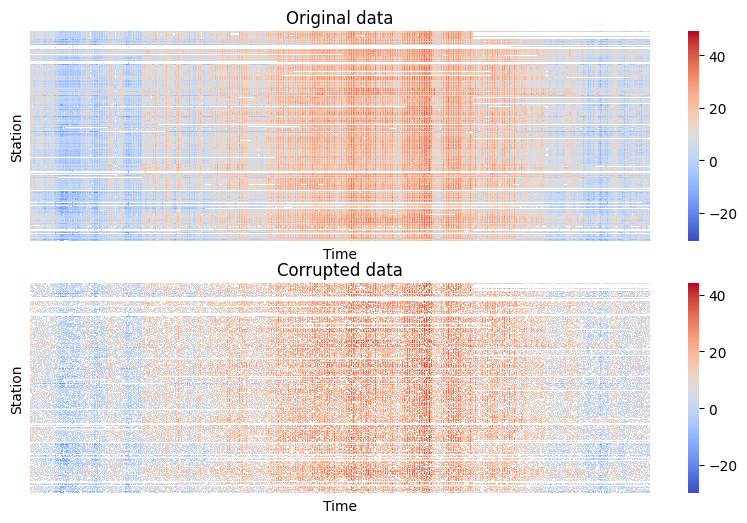

In [9]:
clean_data = data_provider.dataset.data
corrupted_data = data_provider.dataset.corrupted_data

fig, ax = plt.subplots(2, 1, figsize=(10, 6))
sns.heatmap(clean_data.T, xticklabels=False, yticklabels=False, cmap="coolwarm", ax=ax[0])
ax[0].set_title("Original data")
ax[0].set_xlabel("Time")
ax[0].set_ylabel("Station")
sns.heatmap(corrupted_data.T, xticklabels=False, yticklabels=False, cmap="coolwarm", ax=ax[1])
ax[1].set_title("Corrupted data")
ax[1].set_xlabel("Time")
ax[1].set_ylabel("Station")
plt.show()

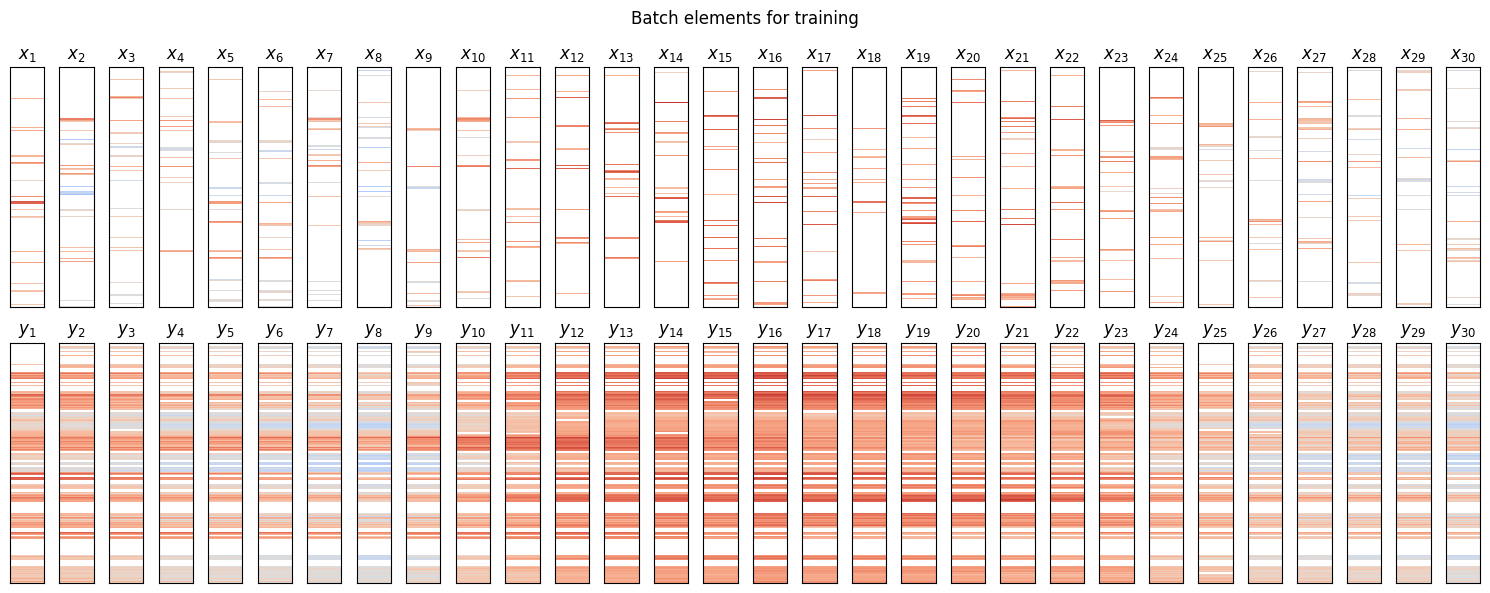

In [10]:
test_dataloader = data_provider.test_dataloader()

plt.figure(figsize=(15, 6))
iterator = 1
for batch in test_dataloader:
    if iterator > 30: 
        break
    plt.subplot(2, 30, iterator) 
    plt.imshow(batch['x'].squeeze(0,-1).numpy()[np.newaxis,:].T, cmap="coolwarm", aspect="auto")
    plt.xlim(0, .5)
    plt.ylim(0, batch['x'].shape[2]*.5)
    plt.xticks([])
    plt.yticks([])
    plt.title(f"$x_{{{iterator}}}$")
    plt.subplot(2, 30, iterator + 30)
    plt.imshow(batch['y'].squeeze(0,-1).numpy()[np.newaxis,:].T, cmap="coolwarm", aspect="auto")
    plt.xlim(0, .5)
    plt.ylim(0, batch['y'].shape[2]*.5)
    plt.xticks([])
    plt.yticks([])
    plt.title(f"$y_{{{iterator}}}$")
    iterator += 1
plt.suptitle('Batch elements for training')
plt.tight_layout()  
plt.show()

### Sequence masking <a class="anchor" id="fourth-bullet"></a>

In [11]:
from data_provider.data_provider import DataProvider
from types import SimpleNamespace

In [12]:
args = SimpleNamespace()
args.data = 'bdclim_clean'
args.dataset = 'SequenceMaskDataset'
args.root_path = '../../datasets/'
args.data_path = 'bdclim_safran_2023-2024.nc'
args.has_predictors = False
args.scaler = None
args.batch_size = 1
args.mask_length = 24*7*3
args.mask_proba = 0.5

data_provider = DataProvider(args)

total stations:  2303  remaining stations:  639  removing every station with NaN values.
device:  cpu


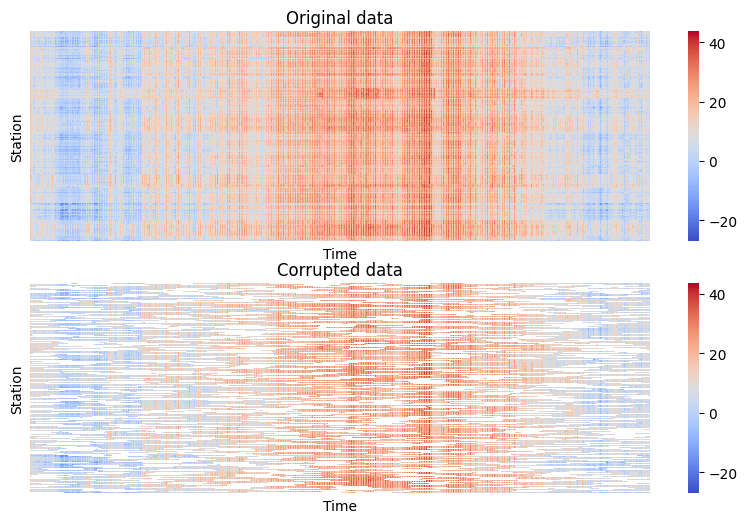

In [13]:
clean_data = data_provider.dataset.data
corrupted_data = data_provider.dataset.corrupted_data

fig, ax = plt.subplots(2, 1, figsize=(10, 6))
sns.heatmap(clean_data.T, xticklabels=False, yticklabels=False, cmap="coolwarm", ax=ax[0])
ax[0].set_title("Original data")
ax[0].set_xlabel("Time")
ax[0].set_ylabel("Station")
sns.heatmap(corrupted_data.T, xticklabels=False, yticklabels=False, cmap="coolwarm", ax=ax[1])
ax[1].set_title("Corrupted data")
ax[1].set_xlabel("Time")
ax[1].set_ylabel("Station")
plt.show()

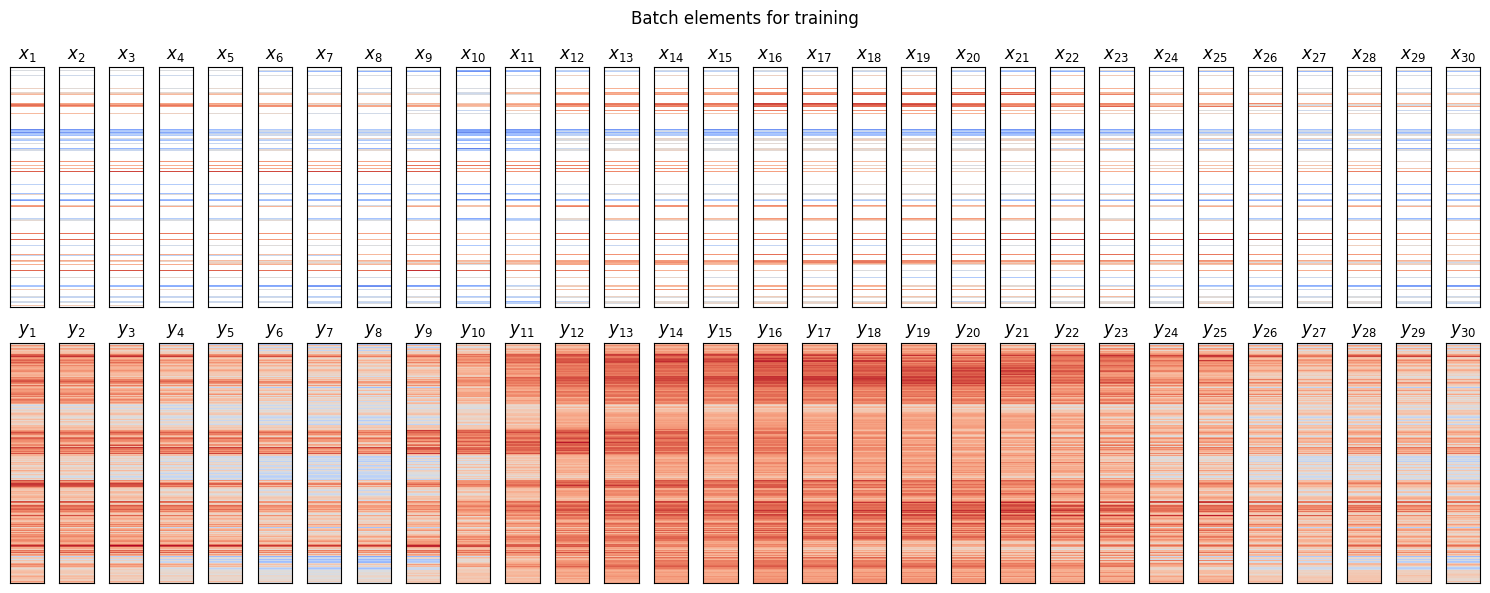

In [14]:
test_dataloader = data_provider.test_dataloader()

plt.figure(figsize=(15, 6))
iterator = 1
for batch in test_dataloader:
    if iterator > 30: 
        break
    plt.subplot(2, 30, iterator) 
    plt.imshow(batch['x'].squeeze(0,-1).numpy()[np.newaxis,:].T, cmap="coolwarm", aspect="auto")
    plt.xlim(0, .5)
    plt.ylim(0, batch['x'].shape[2]*.5)
    plt.xticks([])
    plt.yticks([])
    plt.title(f"$x_{{{iterator}}}$")
    plt.subplot(2, 30, iterator + 30)
    plt.imshow(batch['y'].squeeze(0,-1).numpy()[np.newaxis,:].T, cmap="coolwarm", aspect="auto")
    plt.xlim(0, .5)
    plt.ylim(0, batch['y'].shape[2]*.5)
    plt.xticks([])
    plt.yticks([])
    plt.title(f"$y_{{{iterator}}}$")
    iterator += 1
plt.suptitle('Batch elements for training')
plt.tight_layout()  
plt.show()

### Window-horizon masking <a class="anchor" id="fifth-bullet"></a>

In [15]:
from data_provider.data_provider import DataProvider
from types import SimpleNamespace

In [19]:
args = SimpleNamespace()
args.data = 'bdclim_clean'
args.dataset = 'WindowHorizonDataset'
args.root_path = '../../datasets/'
args.data_path = 'bdclim_safran_2023-2024.nc'
args.has_predictors = False
args.scaler = None
args.batch_size = 1
args.mask_length = 24*7*3
args.window = 24*1*1
args.horizon = 0
args.mask_proba = 0.25

data_provider = DataProvider(args)

total stations:  2303  remaining stations:  639  removing every station with NaN values.
device:  cpu


/Users/leocatteau/Desktop/EPFL/Météo-France/code/Meteo-France/notebook_guides/../data_provider/data_preparation.py:16: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.data = torch.tensor(self.data)


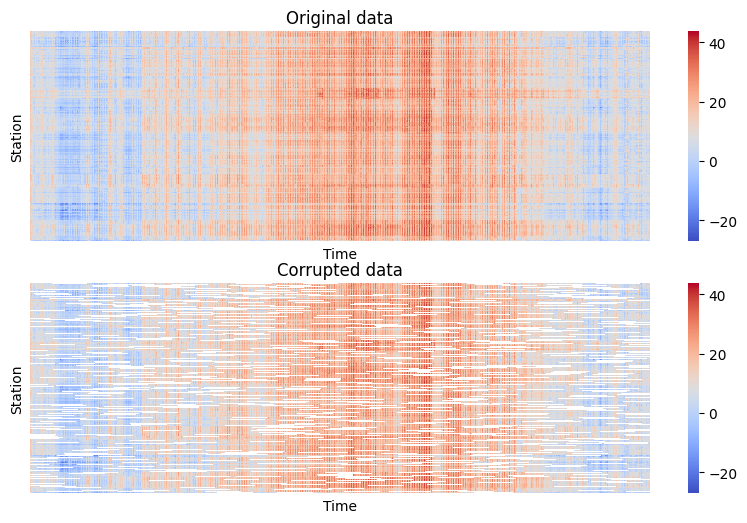

In [20]:
clean_data = data_provider.dataset.data
corrupted_data = data_provider.dataset.corrupted_data

fig, ax = plt.subplots(2, 1, figsize=(10, 6))
sns.heatmap(clean_data.T, xticklabels=False, yticklabels=False, cmap="coolwarm", ax=ax[0])
ax[0].set_title("Original data")
ax[0].set_xlabel("Time")
ax[0].set_ylabel("Station")
sns.heatmap(corrupted_data.T, xticklabels=False, yticklabels=False, cmap="coolwarm", ax=ax[1])
ax[1].set_title("Corrupted data")
ax[1].set_xlabel("Time")
ax[1].set_ylabel("Station")
plt.show()

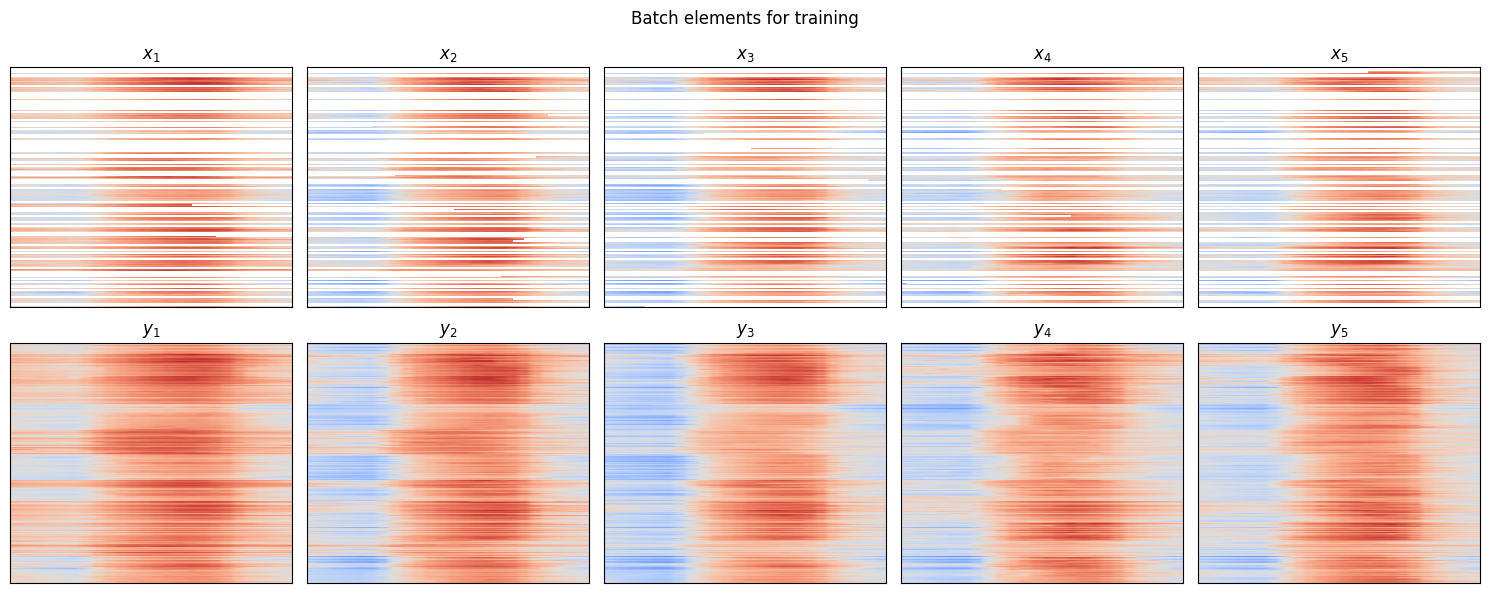

In [21]:
test_dataloader = data_provider.test_dataloader()

plt.figure(figsize=(15, 6))
iterator = 1
for batch in test_dataloader:
    if iterator > 5: 
        break
    plt.subplot(2, 5, iterator) 
    plt.imshow(batch['x'].squeeze(0,-1).numpy().T, cmap="coolwarm", aspect="auto")
    plt.xticks([])
    plt.yticks([])
    plt.ylim(0, batch['x'].shape[2]*.5)
    plt.title(f"$x_{{{iterator}}}$")
    plt.subplot(2, 5, iterator + 5)
    plt.imshow(batch['y'].squeeze(0,-1).numpy().T, cmap="coolwarm", aspect="auto")
    plt.xticks([])
    plt.yticks([])
    plt.ylim(0, batch['y'].shape[2]*.5)
    plt.title(f"$y_{{{iterator}}}$")
    iterator += 1
plt.suptitle('Batch elements for training')
plt.tight_layout()  
plt.show()